# Práctica 1: Regresión Logística - Predicción de Potabilidad del Agua

En este cuaderno se implementa un modelo de **Regresión Logística** desde cero para predecir si el agua es potable o no (`1` o `0`) utilizando el dataset `water_potability.csv`.

Se realizan los siguientes pasos:
1. Carga del conjunto de datos y tratamiento de valores nulos (`NaN`).
2. Normalización de características.
3. División de datos en conjuntos de Entrenamiento (80%) y Prueba (20%).
4. Implementación de funciones clave: `sigmoid`, `calcularCosto`, `descensoGradiente` y `predict`.
5. Optimización de parámetros $\theta$ mediante Descenso por el Gradiente y `scipy.optimize.minimize`.
6. Evaluación de precisión y validación del modelo.

In [99]:
# Esta celda importa librerías para manejo de datos, álgebra y gráficos.
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot
from scipy import optimize
%matplotlib inline

## 1. Carga y Limpieza del Dataset
Cargamos el conjunto de datos `water_potability.csv`. El dataset contiene características fisicoquímicas del agua y la columna objetivo (Potabilidad).
Se realiza una imputación de valores faltantes (`NaN`) mediante la media de cada característica para asegurar la convergencia numérica.

In [100]:
dataset = 'water_potability.csv'
print(f'Archivo a usar: {os.path.abspath(dataset)}')

# Cargar dataset sin encabezado explícito
df = pd.read_csv(dataset, header=None)

# Verificar presencia de valores nulos (NaN) por columna
print("Valores nulos por columna antes de limpiar:")
print(df.isna().sum())

# Imputación de valores nulos utilizando la media de cada columna
df = df.fillna(df.mean())

print("\nTotal de valores nulos tras imputación:", df.isna().sum().sum())

# Extraer matriz de características X y vector de salida y
X = df.iloc[:, :9].values
y = df.iloc[:, 9].values

m = y.size
print(f"\nDimensión de X: {X.shape}")
print(f"Dimensión de y: {y.shape}")
print(f"Tipo de datos de X: {X.dtype}")

Archivo a usar: e:\USFX\7mo Semestre\Inteligencia Artificial\Practicas\practica 1\water_potability.csv
Valores nulos por columna antes de limpiar:
0    491
1      0
2      0
3      0
4    781
5      0
6      0
7    162
8      0
9      0
dtype: int64

Total de valores nulos tras imputación: 0

Dimensión de X: (3276, 9)
Dimensión de y: (3276,)
Tipo de datos de X: float64


## 2. Normalización de Características y Estructuración de Datos
Estandarizamos las características restando la media $\mu$ y dividiendo entre la desviación estándar $\sigma$ (`featureNormalize`). Luego añadimos la columna de unos para el término de intercepción (bias) y dividimos los datos en entrenamiento y prueba.

In [101]:
def featureNormalize(X):
    X_norm = X.copy()
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

# Normalizar X
X_norm, mu, sigma = featureNormalize(X)

# Agregar el término de intercepción a X (columna de 1s)
m, n = X_norm.shape
X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

# División en 80% Entrenamiento y 20% Prueba
np.random.seed(42)
indices = np.random.permutation(m)
corte = int(0.8 * m)
idx_train, idx_test = indices[:corte], indices[corte:]

X_train, X_test = X[idx_train], X[idx_test]
y_train, y_test = y[idx_train], y[idx_test]

print(f"Entrenamiento: {X_train.shape[0]} muestras | Prueba: {X_test.shape[0]} muestras")

Entrenamiento: 2620 muestras | Prueba: 656 muestras


## 3. Implementación de Funciones Principales de Regresión Logística

In [102]:
def sigmoid(z):
    z = np.array(z)
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))

# Prueba de la función sigmoide
z_test = [0, 0.5, 0.75, 1]
print('g(', z_test, ') = ', sigmoid(z_test))

g( [0, 0.5, 0.75, 1] ) =  [0.5        0.62245933 0.6791787  0.73105858]


In [103]:
def calcularCosto(theta, X, y):
    m = y.size
    h = sigmoid(X.dot(theta.T))
    eps = 1e-15
    h = np.clip(h, eps, 1.0 - eps)
    J = (1.0 / m) * np.sum(-y * np.log(h) - (1.0 - y) * np.log(1.0 - h))
    return J

In [104]:
def descensoGradiente(theta, X, y, alpha, num_iters):
    m = y.shape[0]
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        h = sigmoid(X.dot(theta.T))
        theta = theta - (alpha / m) * (h - y).dot(X)
        J_history.append(calcularCosto(theta, X, y))

    return theta, J_history

## 4. Entrenamiento con Descenso por el Gradiente y Gráfica de Costo

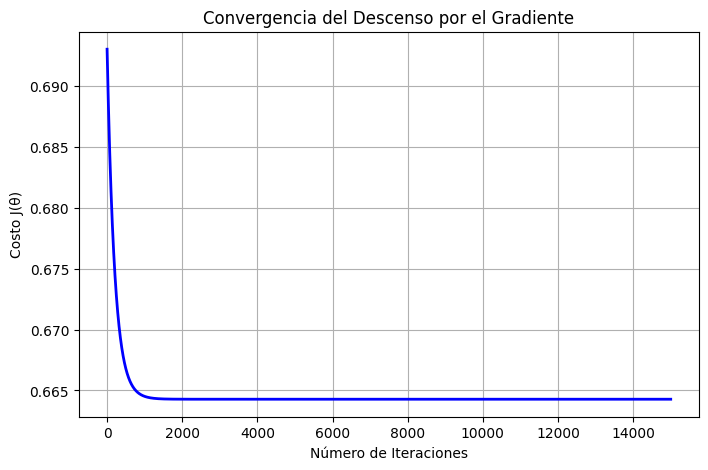

Theta optimizado por Descenso por el Gradiente:
[-0.4690895  -0.02109901 -0.01783646  0.05623796  0.06478952 -0.04364126
 -0.04282039 -0.07158781  0.02612476 -0.016405  ]
Costo final J(θ): 0.6643


In [105]:
# Configuración de hiperparámetros
alpha = 0.01
num_iters = 15000
theta_inicial = np.zeros(X_train.shape[1])

theta_gd, J_history = descensoGradiente(theta_inicial, X_train, y_train, alpha, num_iters)

# Gráfica de convergencia del costo J(theta)
pyplot.figure(figsize=(8, 5))
pyplot.plot(np.arange(len(J_history)), J_history, lw=2, color='b')
pyplot.xlabel('Número de Iteraciones')
pyplot.ylabel('Costo J(θ)')
pyplot.title('Convergencia del Descenso por el Gradiente')
pyplot.grid(True)
pyplot.show()

print('Theta optimizado por Descenso por el Gradiente:')
print(theta_gd)
print(f'Costo final J(θ): {J_history[-1]:.4f}')

## 5. Optimización Avanzada con `scipy.optimize.minimize`

In [106]:
def costFunction(theta, X, y):
    m = y.size
    h = sigmoid(X.dot(theta.T))
    eps = 1e-15
    h = np.clip(h, eps, 1.0 - eps)
    
    J = (1.0 / m) * np.sum(-y * np.log(h) - (1.0 - y) * np.log(1.0 - h))
    grad = (1.0 / m) * (h - y).dot(X)
    
    return J, grad

# Prueba de costFunction
cost_ini, grad_ini = costFunction(theta_inicial, X_train, y_train)
print(f'Costo en theta inicial (ceros): {cost_ini:.4f}')
print('Gradiente inicial:', grad_ini)

Costo en theta inicial (ceros): 0.6931
Gradiente inicial: [ 0.1148855   0.00785923  0.00530197 -0.01515571 -0.01504918  0.01148664
  0.00959763  0.01819546 -0.00790054  0.00419486]


In [107]:
# Optimización mediante Scipy TNC
options = {'maxiter': 1000}
res = optimize.minimize(costFunction,
                        theta_inicial,
                        (X_train, y_train),
                        jac=True,
                        method='TNC',
                        options=options)

cost_scipy = res.fun
theta_scipy = res.x

print(f'Costo optimizado con scipy.optimize.minimize: {cost_scipy:.4f}')
print('Theta optimizado por Scipy:')
print(theta_scipy)

Costo optimizado con scipy.optimize.minimize: 0.6643
Theta optimizado por Scipy:
[-0.46908919 -0.02109823 -0.01783771  0.05623685  0.06478926 -0.04364236
 -0.04282114 -0.07158733  0.02612407 -0.01640491]


C:\Users\luisg\AppData\Local\Temp\ipykernel_34888\2890024704.py:3: OptimizeWarning: Unknown solver options: maxiter
  res = optimize.minimize(costFunction,


## 6. Predicción y Evaluación de Exactitud

In [108]:
def predict(theta, X):
    p = sigmoid(X.dot(theta.T)) >= 0.5
    return p.astype(int)

# Evaluación para Descenso por el Gradiente
p_train_gd = predict(theta_gd, X_train)
p_test_gd = predict(theta_gd, X_test)
acc_train_gd = np.mean(p_train_gd == y_train) * 100
acc_test_gd = np.mean(p_test_gd == y_test) * 100

print("=== EXACTITUD (Descenso por el Gradiente) ===")
print(f"Precisión Entrenamiento: {acc_train_gd:.2f}%")
print(f"Precisión Prueba: {acc_test_gd:.2f}%")

# Evaluación para Scipy Minimize
p_train_scipy = predict(theta_scipy, X_train)
p_test_scipy = predict(theta_scipy, X_test)
acc_train_scipy = np.mean(p_train_scipy == y_train) * 100
acc_test_scipy = np.mean(p_test_scipy == y_test) * 100

print("\n=== EXACTITUD (Scipy Optimize) ===")
print(f"Precisión Entrenamiento: {acc_train_scipy:.2f}%")
print(f"Precisión Prueba: {acc_test_scipy:.2f}%")

=== EXACTITUD (Descenso por el Gradiente) ===
Precisión Entrenamiento: 61.56%
Precisión Prueba: 58.99%

=== EXACTITUD (Scipy Optimize) ===
Precisión Entrenamiento: 61.56%
Precisión Prueba: 58.99%


In [ ]:
# Predicciones individuales sobre muestras de prueba
print("Muestra\t\tProbabilidad\tPredicción\tReal")
print("-" * 55)

#se probara cualquier fila random

probs = sigmoid(X_test[:600].dot(theta_gd.T))
preds = predict(theta_gd, X_test[:600])
reales = y_test[:600]

for i in range(600):
    print(f"Muestra {i+1}:\t{probs[i]:.4f}\t\t{preds[i]}\t\t{reales[i]}")

Muestra		Probabilidad	Predicción	Real
-------------------------------------------------------
Muestra 1:	0.3889		0		0
Muestra 2:	0.3823		0		1
Muestra 3:	0.3471		0		0
Muestra 4:	0.3713		0		0
Muestra 5:	0.4064		0		0
Muestra 6:	0.4180		0		1
Muestra 7:	0.3818		0		1
Muestra 8:	0.4245		0		0
Muestra 9:	0.3544		0		1
Muestra 10:	0.4191		0		1
Muestra 11:	0.4125		0		1
Muestra 12:	0.3567		0		1
Muestra 13:	0.3943		0		1
Muestra 14:	0.4234		0		0
Muestra 15:	0.4254		0		0
Muestra 16:	0.3673		0		0
Muestra 17:	0.4235		0		1
Muestra 18:	0.4051		0		0
Muestra 19:	0.3299		0		0
Muestra 20:	0.3768		0		1
Muestra 21:	0.4105		0		1
Muestra 22:	0.3115		0		1
Muestra 23:	0.3558		0		0
Muestra 24:	0.3872		0		0
Muestra 25:	0.3359		0		0
Muestra 26:	0.4025		0		1
Muestra 27:	0.3913		0		1
Muestra 28:	0.3764		0		0
Muestra 29:	0.4138		0		1
Muestra 30:	0.3718		0		1
Muestra 31:	0.2940		0		1
Muestra 32:	0.3538		0		1
Muestra 33:	0.3641		0		0
Muestra 34:	0.4021		0		1
Muestra 35:	0.3300		0		0
Muestra 36:	0.3581		0		0
Muestra 37:	0.4